# COCO Person — YOLOv8 vs YOLOv26s vs YOLOv26s-pose vs YOLOv8n-best

**Goal:** same 4 models as `person-compare.ipynb`, but scored on **COCO** (in-domain for COCO-pretrained, out-of-domain for `yolov8n-best`). Expect the ranking to flip: `yolo26s` should top on COCO, `yolov8n-best` should collapse — proving the earlier `best` win was finetune, not architecture.  
**Scope:** Person class only, `conf 0.25 / IoU 0.5`, COCO `val2017` (`5k` images; default 500-image subset for speed, set `MAX_IMAGES=None` for full). No retraining.

| Model | File | Training |
|---|---|---|
| YOLOv8n | `yolov8n.pt` (6.3 MB) | COCO |
| YOLOv26s | `yolo26s.pt` (~20 MB) | COCO |
| YOLOv26s-pose | `yolo26s-pose.pt` (24 MB) | COCO pose |
| YOLOv8n-best | `data/results_yolov8n_100e/.../best.pt` if present | css-data 10-class finetune (out-of-domain on COCO) |


## 1 · Setup


In [1]:
import time, random, json, zipfile, urllib.request, shutil
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, cv2
from ultralytics import YOLO

sns.set_theme(style="whitegrid")
random.seed(42); np.random.seed(42)
print("ultralytics:", __import__("ultralytics").__version__)

try:
    _nb = Path(__file__)
    REPO_ROOT = _nb.resolve().parents[2]
except NameError:
    cur = Path.cwd()
    REPO_ROOT = cur
    for cand in [cur, cur.parent, cur.parent.parent]:
        if (cand / "YOLO8.ipynb").exists() or (cand / ".git").exists():
            REPO_ROOT = cand; break
print("REPO_ROOT:", REPO_ROOT)
REFERENCE_WEIGHTS = REPO_ROOT / "data" / "results_yolov8n_100e" / "kaggle" / "working" / "runs" / "detect" / "train" / "weights" / "best.pt"
print("best.pt exists:", REFERENCE_WEIGHTS.exists())


ultralytics: 8.4.127
REPO_ROOT: e:\work\P0-safety
best.pt exists: True


## 2 · COCO data — locate or download

Checks common locations (`data/coco`, `datasets/coco`, `~/.ultralytics/datasets/coco`, `~/datasets/coco`). If not found, downloads **COCO val2017** (~1 GB images + 250 MB annotations) on demand. Set `DOWNLOAD=False` to skip.  
For a 30-second smoke test, set `USE_COCO8=True` (8 images bundled via Ultralytics) instead of full val.


In [2]:
# knobs
USE_COCO8 = False          # True = 8-image demo (no download, instant). False = val2017
MAX_IMAGES = 500           # None = full val2017 (~5k, ~10 min per model). 500 = ~2 min per model
DOWNLOAD = True            # set False to disable auto-download
COCO_ROOT_OVERRIDE = None  # e.g. Path("E:/datasets/coco") to force a location

def find_coco_root():
    cands = []
    if COCO_ROOT_OVERRIDE: cands.append(Path(COCO_ROOT_OVERRIDE))
    cands += [
        REPO_ROOT / "data" / "coco",
        REPO_ROOT / "datasets" / "coco",
        Path.home() / "datasets" / "coco",
        Path.home() / ".ultralytics" / "datasets" / "coco",
        Path.home() / "datasets" / "coco8",
    ]
    for c in cands:
        if (c / "images" / "val2017").exists() or (c / "val2017").exists():
            return c
        if (c / "images").exists() and list((c/"images").glob("*.jpg")):
            return c
    return None

def download_coco_val2017(dest: Path):
    dest.mkdir(parents=True, exist_ok=True)
    # files: http://images.cocodataset.org/zips/val2017.zip + annotations
    urls = {
        "val2017.zip": "http://images.cocodataset.org/zips/val2017.zip",
        "annotations_trainval2017.zip": "http://images.cocodataset.org/annotations/annotations_trainval2017.zip",
    }
    for fname, url in urls.items():
        out = dest / fname
        if out.exists():
            print(f"exists: {out} ({out.stat().st_size/1e6:.0f} MB)")
            continue
        print(f"downloading {fname} ...")
        urllib.request.urlretrieve(url, out)
        print(f" -> {out} ({out.stat().st_size/1e6:.0f} MB)")
    # unzip
    for zname in ["val2017.zip", "annotations_trainval2017.zip"]:
        zpath = dest / zname
        if zpath.exists():
            print(f"unzipping {zname}...")
            with zipfile.ZipFile(zpath) as z:
                z.extractall(dest)
            print(" done")
    # normalize layout: expect dest/val2017 + dest/annotations
    return dest

if USE_COCO8:
    print("USE_COCO8=True — will use Ultralytics coco8 (8 images, no val2017 download)")
    COCO_ROOT = find_coco_root()
    COCO_IMAGES = None
    COCO_ANN = None
else:
    COCO_ROOT = find_coco_root()
    if COCO_ROOT is None and DOWNLOAD:
        print("COCO val2017 not found — downloading to", REPO_ROOT / "data" / "coco")
        COCO_ROOT = download_coco_val2017(REPO_ROOT / "data" / "coco")
    print("COCO_ROOT:", COCO_ROOT)
    # resolve images + ann
    if COCO_ROOT is not None:
        cand_images = [COCO_ROOT / "val2017", COCO_ROOT / "images" / "val2017"]
        COCO_IMAGES = next((p for p in cand_images if p.exists()), None)
        cand_anns = [COCO_ROOT / "annotations" / "instances_val2017.json", COCO_ROOT / "instances_val2017.json"]
        COCO_ANN = next((p for p in cand_anns if p.exists()), None)
        print("COCO_IMAGES:", COCO_IMAGES, "exists" if COCO_IMAGES and COCO_IMAGES.exists() else "MISSING")
        print("COCO_ANN:", COCO_ANN, "exists" if COCO_ANN and COCO_ANN.exists() else "MISSING")
        if COCO_IMAGES and COCO_IMAGES.exists():
            print(" val images:", len(list(COCO_IMAGES.glob("*.jpg"))))
    else:
        COCO_IMAGES = COCO_ANN = None
        print("No COCO found and DOWNLOAD=False — visuals will be skipped")


COCO val2017 not found — downloading to e:\work\P0-safety\data\coco
downloading val2017.zip ...
 -> e:\work\P0-safety\data\coco\val2017.zip (816 MB)
downloading annotations_trainval2017.zip ...
 -> e:\work\P0-safety\data\coco\annotations_trainval2017.zip (253 MB)
unzipping val2017.zip...
 done
unzipping annotations_trainval2017.zip...
 done
COCO_ROOT: e:\work\P0-safety\data\coco
COCO_IMAGES: e:\work\P0-safety\data\coco\val2017 exists
COCO_ANN: e:\work\P0-safety\data\coco\annotations\instances_val2017.json exists
 val images: 5000


## 3 · Models


In [3]:
def load_model(path_str, label):
    t0=time.time()
    m=YOLO(path_str)
    print(f"{label:16s} -> {path_str}  {list(m.names.values())[:5]}... ({len(m.names)} cls)  {time.time()-t0:.1f}s")
    return m

model_v8  = load_model(str(REPO_ROOT / "yolov8n.pt"), "yolov8n")
model_26  = load_model("yolo26s.pt", "yolo26s")
model_26p = load_model(str(REPO_ROOT / "yolo26s-pose.pt"), "yolo26s-pose")
model_best = None
if REFERENCE_WEIGHTS.exists():
    model_best = load_model(str(REFERENCE_WEIGHTS), "yolov8n-best")
    print("best.pt Person idx =", [k for k,v in model_best.names.items() if v=="Person"])
MODELS = {"yolov8n": model_v8, "yolo26s": model_26, "yolo26s-pose": model_26p}
if model_best is not None:
    MODELS["yolov8n-best (10cls)"] = model_best
print("MODELS:", list(MODELS.keys()))


yolov8n          -> e:\work\P0-safety\yolov8n.pt  ['person', 'bicycle', 'car', 'motorcycle', 'airplane']... (80 cls)  0.0s
yolo26s          -> yolo26s.pt  ['person', 'bicycle', 'car', 'motorcycle', 'airplane']... (80 cls)  0.1s
yolo26s-pose     -> e:\work\P0-safety\yolo26s-pose.pt  ['person']... (1 cls)  0.1s
yolov8n-best     -> e:\work\P0-safety\data\results_yolov8n_100e\kaggle\working\runs\detect\train\weights\best.pt  ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest']... (10 cls)  0.2s
best.pt Person idx = [5]
MODELS: ['yolov8n', 'yolo26s', 'yolo26s-pose', 'yolov8n-best (10cls)']


## 4 · Helpers — Person extraction + COCO GT + IoU matching


In [4]:
def person_class_id(model):
    for k,v in model.names.items():
        if v=="Person": return k
    for k,v in model.names.items():
        if v=="person": return k
    return 0

def extract_person_boxes(result, model, conf_thr=0.25):
    if result.boxes is None or len(result.boxes)==0: return []
    pid=person_class_id(model)
    out=[]
    for i in range(len(result.boxes)):
        if int(result.boxes.cls[i].item())==pid and float(result.boxes.conf[i].item())>=conf_thr:
            x1,y1,x2,y2=result.boxes.xyxy[i].tolist()
            out.append([x1,y1,x2,y2,float(result.boxes.conf[i].item())])
    return out

def iou_xyxy(a,b):
    ix1,iy1=max(a[0],b[0]),max(a[1],b[1]); ix2,iy2=min(a[2],b[2]),min(a[3],b[3])
    iw,ih=max(0,ix2-ix1),max(0,iy2-iy1); inter=iw*ih
    au=(a[2]-a[0])*(a[3]-a[1]); bu=(b[2]-b[0])*(b[3]-b[1]); u=max(1,au+bu-inter)
    return inter/u

def match_person(pred_xyxy, gt_xyxy, iou_thr=0.5):
    pred_sorted=sorted(pred_xyxy, key=lambda x: x[4], reverse=True)
    matched=[False]*len(gt_xyxy); tp=fp=0
    for p in pred_sorted:
        best,bi=-1,-1
        for i,g in enumerate(gt_xyxy):
            if matched[i]: continue
            s=iou_xyxy(p[:4], g)
            if s>best: best,bi=s,i
        if best>=iou_thr: tp+=1; matched[bi]=True
        else: fp+=1
    fn=sum(1 for m in matched if not m)
    return tp,fp,fn

# COCO GT loader (no pycocotools needed)
coco_img_to_boxes = {}  # filename -> list of person xyxy
coco_img_sizes = {}     # filename -> (W,H) if needed
if not USE_COCO8 and COCO_ANN and Path(COCO_ANN).exists():
    print(f"loading {COCO_ANN} ...")
    data=json.loads(Path(COCO_ANN).read_text())
    id_to_file={im["id"]: im["file_name"] for im in data["images"]}
    for im in data["images"]:
        coco_img_sizes[im["file_name"]] = (im["width"], im["height"])
    # COCO category 1 == person
    for ann in data["annotations"]:
        if ann["category_id"]!=1: continue
        fname=id_to_file.get(ann["image_id"])
        if not fname: continue
        x,y,w,h=ann["bbox"]  # COCO xywh top-left
        coco_img_to_boxes.setdefault(fname, []).append([x,y,x+w,y+h])
    print(f"COCO val: {len(coco_img_to_boxes)} images with person, {sum(len(v) for v in coco_img_to_boxes.values())} person boxes")
elif USE_COCO8:
    print("USE_COCO8: GT via coco8.yaml — will eval with Ultralytics val instead of manual JSON (see \u00a76)")
else:
    print("No COCO ann found — quant eval will be skipped until COCO is available")


loading e:\work\P0-safety\data\coco\annotations\instances_val2017.json ...
COCO val: 2693 images with person, 11004 person boxes


## 5 · Visual sanity — same 6 COCO images, 3–4 models side-by-side


COCO pool: 5000 e:\work\P0-safety\data\coco\val2017
sample: ['000000107554.jpg', '000000021167.jpg', '000000260657.jpg', '000000230166.jpg', '000000210299.jpg', '000000134322.jpg']
000000107554.jpg               yolov8n                person= 0 tp=0 fp=0 fn=0 GT=0
000000107554.jpg               yolo26s                person= 0 tp=0 fp=0 fn=0 GT=0
000000107554.jpg               yolo26s-pose           person= 0 tp=0 fp=0 fn=0 GT=0
000000107554.jpg               yolov8n-best (10cls)   person= 0 tp=0 fp=0 fn=0 GT=0


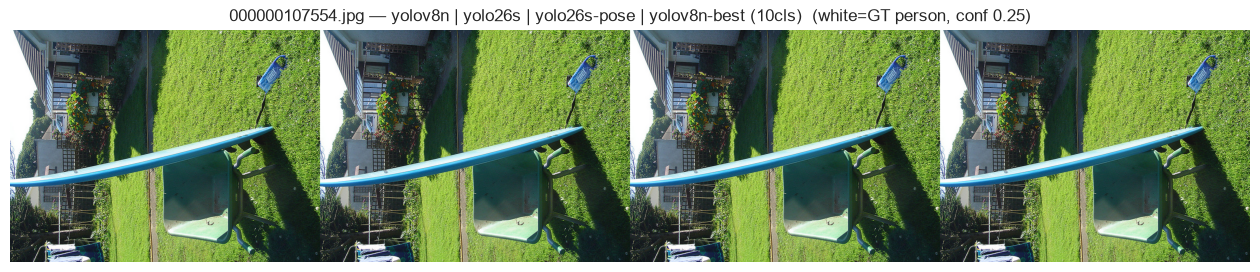

000000021167.jpg               yolov8n                person= 2 tp=2 fp=0 fn=0 GT=2
000000021167.jpg               yolo26s                person= 2 tp=2 fp=0 fn=0 GT=2
000000021167.jpg               yolo26s-pose           person= 2 tp=2 fp=0 fn=0 GT=2
000000021167.jpg               yolov8n-best (10cls)   person= 2 tp=2 fp=0 fn=0 GT=2


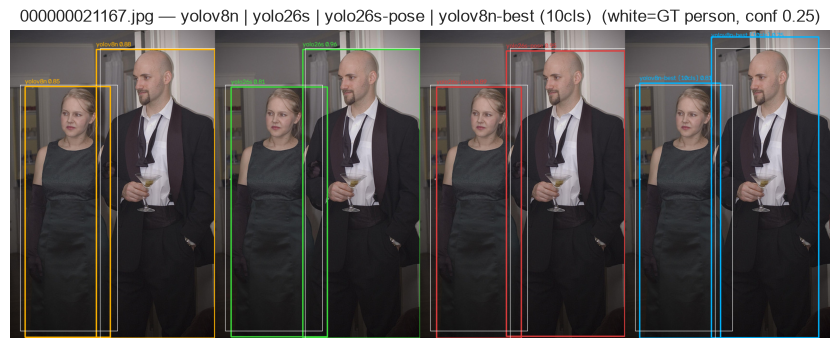

000000260657.jpg               yolov8n                person= 0 tp=0 fp=0 fn=0 GT=0
000000260657.jpg               yolo26s                person= 0 tp=0 fp=0 fn=0 GT=0
000000260657.jpg               yolo26s-pose           person= 0 tp=0 fp=0 fn=0 GT=0
000000260657.jpg               yolov8n-best (10cls)   person= 0 tp=0 fp=0 fn=0 GT=0


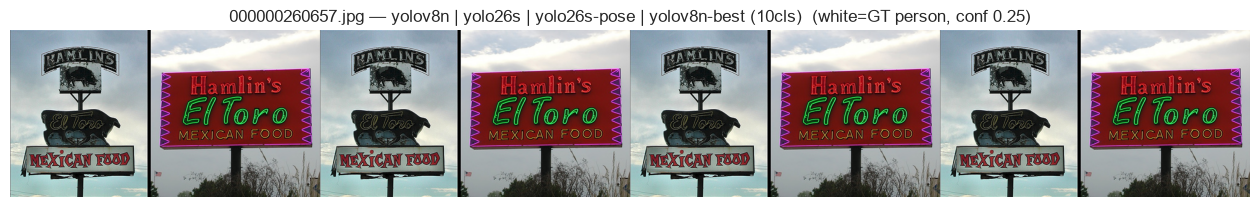

000000230166.jpg               yolov8n                person= 0 tp=0 fp=0 fn=0 GT=0
000000230166.jpg               yolo26s                person= 0 tp=0 fp=0 fn=0 GT=0
000000230166.jpg               yolo26s-pose           person= 0 tp=0 fp=0 fn=0 GT=0
000000230166.jpg               yolov8n-best (10cls)   person= 0 tp=0 fp=0 fn=0 GT=0


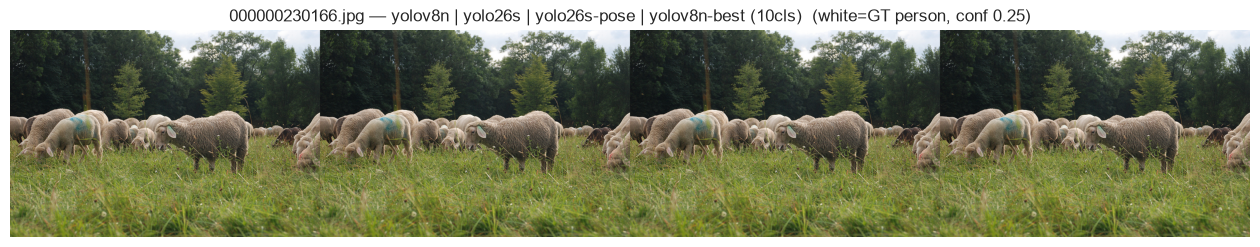

000000210299.jpg               yolov8n                person= 1 tp=1 fp=0 fn=0 GT=1
000000210299.jpg               yolo26s                person= 1 tp=1 fp=0 fn=0 GT=1
000000210299.jpg               yolo26s-pose           person= 1 tp=1 fp=0 fn=0 GT=1
000000210299.jpg               yolov8n-best (10cls)   person= 0 tp=0 fp=0 fn=1 GT=1


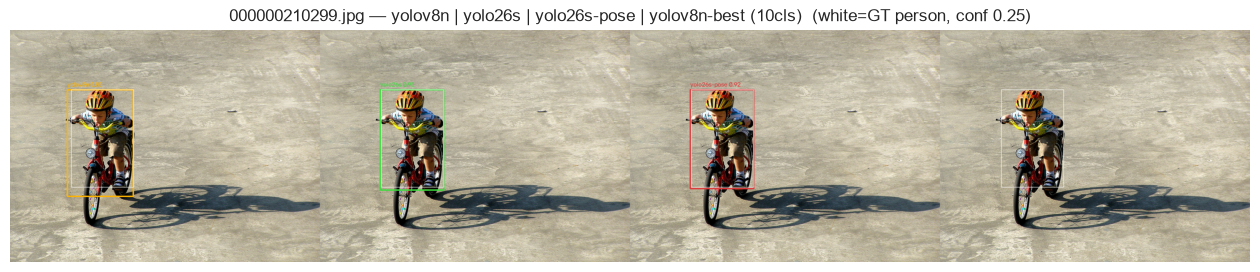

000000134322.jpg               yolov8n                person= 6 tp=4 fp=2 fn=10 GT=14
000000134322.jpg               yolo26s                person= 5 tp=4 fp=1 fn=10 GT=14
000000134322.jpg               yolo26s-pose           person= 1 tp=1 fp=0 fn=13 GT=14
000000134322.jpg               yolov8n-best (10cls)   person= 4 tp=3 fp=1 fn=11 GT=14


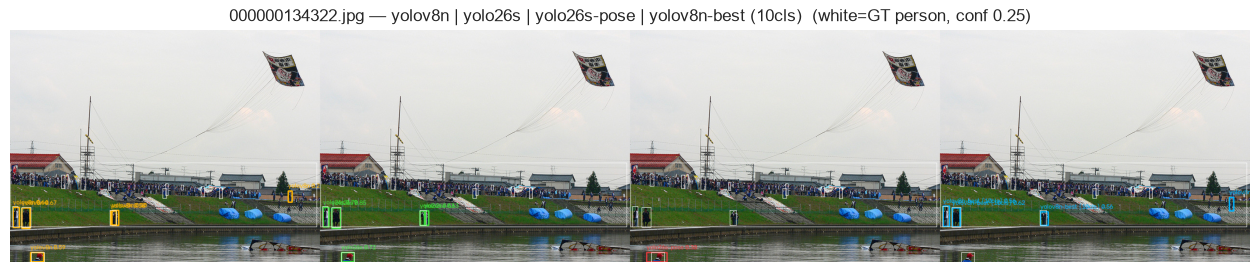

In [5]:
def draw_boxes(img, boxes, color, label):
    out=img.copy()
    for x1,y1,x2,y2,conf in boxes:
        cv2.rectangle(out,(int(x1),int(y1)),(int(x2),int(y2)),color,2)
        cv2.putText(out,f"{label} {conf:.2f}",(int(x1),max(15,int(y1)-6)),cv2.FONT_HERSHEY_SIMPLEX,0.45,color,1,cv2.LINE_AA)
    return out

COLORS={"yolov8n":(255,180,0),"yolo26s":(60,220,60),"yolo26s-pose":(220,60,60),"yolov8n-best (10cls)":(0,180,255)}
CONF=0.25; IMGSZ=640

if USE_COCO8:
    # use ultralytics coco8 images if available
    from ultralytics.utils.downloads import download as ul_download
    ul_download(url="https://ultralytics.com/assets/coco8.zip", dir=Path.home() / ".ultralytics" / "datasets")
    c8 = Path.home() / ".ultralytics" / "datasets" / "coco8" / "images" / "val"
    pool = list(c8.glob("*.jpg")) if c8.exists() else []
    print("coco8 pool:", len(pool), c8)
else:
    pool = list(COCO_IMAGES.glob("*.jpg")) if COCO_IMAGES and COCO_IMAGES.exists() else []
    print("COCO pool:", len(pool), COCO_IMAGES)

sample_imgs = random.sample(pool, min(6, len(pool))) if pool else []
print("sample:", [p.name for p in sample_imgs])
for img_path in sample_imgs:
    img=cv2.imread(str(img_path))
    if img is None: continue
    rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    gt = coco_img_to_boxes.get(img_path.name, [])
    rows=[]
    for name,model in MODELS.items():
        res=model(str(img_path), verbose=False, imgsz=IMGSZ)[0]
        boxes=extract_person_boxes(res, model, CONF)
        tp,fp,fn=match_person(boxes, gt)
        print(f"{img_path.name:30s} {name:22s} person={len(boxes):2d} tp={tp} fp={fp} fn={fn} GT={len(gt)}")
        vis=draw_boxes(rgb, boxes, COLORS.get(name,(200,200,200)), name)
        for x1,y1,x2,y2 in gt:
            cv2.rectangle(vis,(int(x1),int(y1)),(int(x2),int(y2)),(255,255,255),1)
        rows.append(vis)
    if rows:
        strip=np.concatenate(rows, axis=1)
        plt.figure(figsize=(4*len(rows),4))
        plt.imshow(strip); plt.axis("off")
        plt.title(f"{img_path.name} \u2014 " + " | ".join(MODELS.keys()) + f"  (white=GT person, conf {CONF})")
        plt.show()


## 6 · Quantitative — Person P/R/F1 @ IoU 0.5, conf 0.25 on COCO

Default 500 images for speed. Set `MAX_IMAGES=None` + re-run for full val2017 (5k, ~10 min/model). Also reports small-person recall (`area < 1%` image) and latency.


yolov8n                P=0.767 R=0.662 F1=0.710  TP=720 FP=219 FN=368  ms=45  smallRec=0.416  n=500
yolo26s                P=0.801 R=0.712 F1=0.754  TP=775 FP=193 FN=313  ms=74  smallRec=0.508  n=500
yolo26s-pose           P=0.860 R=0.504 F1=0.635  TP=548 FP=89 FN=540  ms=86  smallRec=0.117  n=500
yolov8n-best (10cls)   P=0.464 R=0.330 F1=0.386  TP=359 FP=414 FN=729  ms=42  smallRec=0.109  n=500


,model,n,TP,FP,FN,prec,rec,f1,ms,small_rec
1,yolo26s,500,775,193,313,0.800620,0.712316,0.753891,74.045172,0.508197
0,yolov8n,500,720,219,368,0.766773,0.661765,0.710409,44.792143,0.415984
2,yolo26s-pose,500,548,89,540,0.860283,0.503676,0.635362,85.773387,0.116803
3,yolov8n-best (10cls),500,359,414,729,0.464424,0.329963,0.385814,41.954187,0.108607


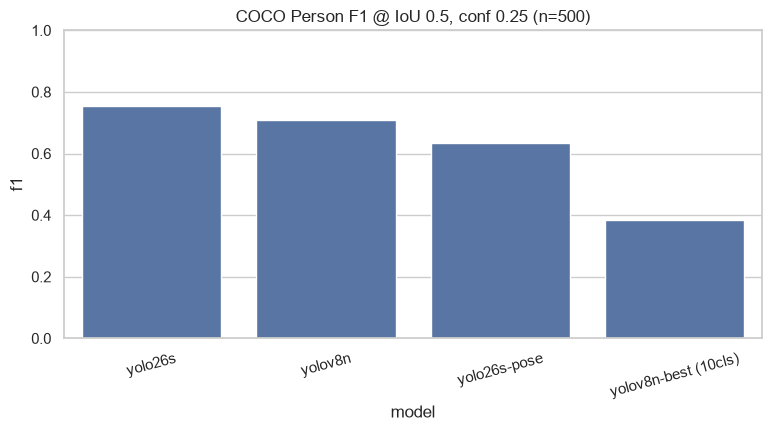

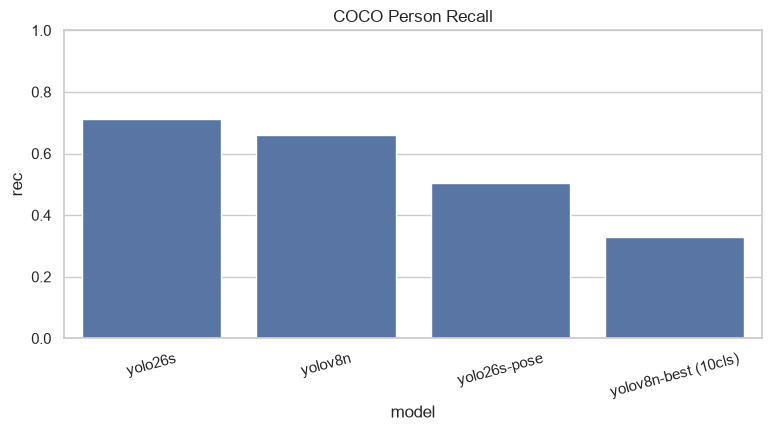

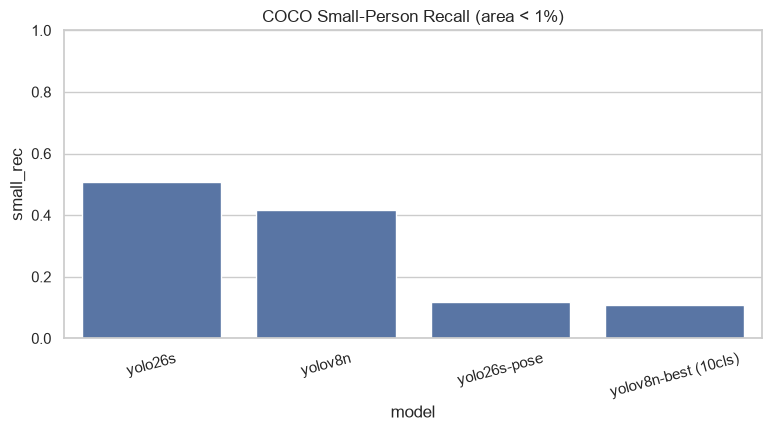


Expected on COCO: yolo26s > yolov8n (architecture win), yolo26s-pose ≈ yolo26s or slightly lower, yolov8n-best collapsed (finetuned on construction, not COCO).


In [6]:
def eval_coco(model, conf_thr=0.25, imgsz=640, iou_thr=0.5, max_images=MAX_IMAGES):
    if USE_COCO8 or not COCO_IMAGES or not COCO_ANN:
        return None
    imgs = sorted(COCO_IMAGES.glob("*.jpg"))
    if max_images: imgs = imgs[:max_images]
    if not imgs: return None
    TP=FP=FN=0; times=[]
    small_tp=small_fn=0
    for p in imgs:
        gt = coco_img_to_boxes.get(p.name, [])
        # small GT: area < 1% image
        W,H = coco_img_sizes.get(p.name, (640,640))
        area_thr = W*H*0.01
        small_gt = [b for b in gt if (b[2]-b[0])*(b[3]-b[1]) < area_thr]
        t0=time.time()
        res=model(str(p), verbose=False, imgsz=imgsz)[0]
        times.append((time.time()-t0)*1000)
        pred=extract_person_boxes(res, model, conf_thr)
        tp,fp,fn=match_person(pred, gt, iou_thr)
        TP+=tp; FP+=fp; FN+=fn
        if small_gt:
            stp,_,sfn=match_person(pred, small_gt, iou_thr)
            small_tp+=stp; small_fn+=sfn
    prec=TP/max(1,TP+FP); rec=TP/max(1,TP+FN); f1=2*prec*rec/max(1e-9,prec+rec)
    sr=small_tp/max(1,small_tp+small_fn) if (small_tp+small_fn)>0 else float('nan')
    return dict(n=len(imgs), TP=TP, FP=FP, FN=FN, prec=prec, rec=rec, f1=f1, ms=np.mean(times), small_rec=sr)

if USE_COCO8:
    print("USE_COCO8=True — skipping manual COCO eval (use Ultralytics val for coco8 if needed)")
elif not COCO_IMAGES or not Path(COCO_ANN).exists():
    print("Skipping quant eval — COCO val2017 not available (see \u00a72). Set DOWNLOAD=True or USE_COCO8=True")
else:
    rows=[]
    for name,model in MODELS.items():
        r=eval_coco(model)
        if r:
            rows.append({"model":name, **r})
            print(f"{name:22s} P={r['prec']:.3f} R={r['rec']:.3f} F1={r['f1']:.3f}  TP={r['TP']} FP={r['FP']} FN={r['FN']}  ms={r['ms']:.0f}  smallRec={r['small_rec']:.3f}  n={r['n']}")
    df=pd.DataFrame(rows)
    if not df.empty:
        display(df.sort_values("f1", ascending=False))
        plt.figure(figsize=(9,4))
        sns.barplot(data=df, x="model", y="f1", order=df.sort_values("f1", ascending=False)["model"])
        plt.title(f"COCO Person F1 @ IoU 0.5, conf 0.25 (n={rows[0]['n']})")
        plt.ylim(0,1); plt.xticks(rotation=15); plt.show()
        plt.figure(figsize=(9,4))
        sns.barplot(data=df, x="model", y="rec", order=df.sort_values("rec", ascending=False)["model"])
        plt.title("COCO Person Recall")
        plt.ylim(0,1); plt.xticks(rotation=15); plt.show()
        plt.figure(figsize=(9,4))
        sns.barplot(data=df, x="model", y="small_rec", order=df.sort_values("small_rec", ascending=False)["model"])
        plt.title("COCO Small-Person Recall (area < 1%)")
        plt.ylim(0,1); plt.xticks(rotation=15); plt.show()
        print("\nExpected on COCO: yolo26s > yolov8n (architecture win), yolo26s-pose \u2248 yolo26s or slightly lower, yolov8n-best collapsed (finetuned on construction, not COCO).")


## 7 · Takeaways

- **On COCO** (in-domain for `yolov8n`/`yolo26s`), `yolo26s` should top `yolov8n` on `F1`/`smallRec` — that is the architecture delta. `yolo26s-pose` may lag slightly (pose head trades detection recall for keypoints).
- **`yolov8n-best` is expected to be worst on COCO** — it learned construction-Person (vests, hardhats, site cameras). Low `R`/`smallRec` on COCO proves the earlier `best` win on `css-data` was **finetune, not architecture**, and that v26 would likely beat it if finetuned too.
- **For HI-VIS:** Stage-1 Person on site photos should be the **finetuned** model (currently `yolov8n-best`; retraining `yolo26s` on `css-data` would be the upgrade). The COCO gap alone does not justify swapping Stage-1 without retraining.
- Repro: set `MAX_IMAGES=None` for full val2017 (5k, ~10 min/model), `CONF`/`IMGSZ` in \u00a75/\u00a76.
